# [LAB-13] 5. ARIMA 모델링

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 차수 조합을 만들기 위한 도구
from itertools import product

# ARIMA · SARIMA 모형
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 차수 조합을 여러 개 적합하면 수렴 경고가 반복 출력되므로 경고를 숨긴다
import warnings
warnings.filterwarnings("ignore")

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 및 인덱스 설정

In [2]:
origin = load_data('air_passengers')

df = my_ts.set_index(origin, "Month", freq="MS")

print(f"데이터셋 크기: {df.shape[0]}행")
print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m}")

df.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


데이터셋 크기: 144행
기간: 1949-01 ~ 1960-12


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 3. 1~4단원이 확정한 파라미터

In [3]:
d = 1             # 1단원 : 일반차분 1회
D = 1             # 1단원 : 계절차분 1회
s = 12            # 1 · 2 · 3단원 : 계절 주기
p = 1             # 4단원 : AR(1) 모형
q = 1             # 4단원 : MA(1) 모형
P = 1             # 4단원 : 계절 AR(1) 모형
Q = 1             # 4단원 : 계절 MA(1) 모형

print(f"p 상한={p}, 차분 d={d}, q 상한={q}")
print(f"P 상한={P}, 계절차분 D={D}, Q 상한={Q}, 계절주기 s={s}")
print(f"모형 차수: ARIMA({p},{d},{q}) x ({P},{D},{Q})_{s}")

p 상한=1, 차분 d=1, q 상한=1
P 상한=1, 계절차분 D=1, Q 상한=1, 계절주기 s=12
모형 차수: ARIMA(1,1,1) x (1,1,1)_12


## #02. ARIMA 모형 적합

### 1. 모형에 넣을 데이터 만들기

로그만 취하고 **차분은 하지 않는다.**

In [4]:
log_s = np.log(df["Passengers"])
log_s.name = "log_Passengers"
log_s.head()

Month
1949-01-01   4.718
1949-02-01   4.771
1949-03-01   4.883
1949-04-01   4.860
1949-05-01   4.796
Freq: MS, Name: log_Passengers, dtype: float64

### 2. 모형 적합

In [5]:
# 차수는 1~4단원이 인계한 값을 그대로 쓴다
model = SARIMAX(log_s, order=(0, d, 1), seasonal_order=(0, D, 1, s))

# disp=False로 지정하면 적합 과정에서 반복되는 로그 메시지를 숨긴다
fit = model.fit(disp=False)

print(fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     log_Passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 244.696
Date:                            Mon, 10 Aug 2026   AIC                           -483.393
Time:                                    04:01:47   BIC                           -474.767
Sample:                                01-01-1949   HQIC                          -479.888
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4017      0.073     -5.502      0.000      -0.545      -0.259
ma.S.L12      -0.5566      0.096   

#### 💡 인사이트

| 변수 | 계수 | 유의확률 | 해석 |
|---|---|---|---|
| `ma.L1` | **−0.402** | <0.001 | 지난달에 실제가 예측보다 **높게** 나왔으면 이번 달은 **낮춰** 잡는다 |
| `ma.S.L12` | **−0.557** | <0.001 | 작년 같은 달의 오차를 **더 강하게** 반영한다 |
| `sigma2` | 0.0013 | <0.001 | 로그 스케일 잔차 분산. 매우 작다 |

- **두 계수 모두 p < 0.001 로 강하게 유의하다.** 군더더기 없는 모형이다.
- 계수가 **음수**인 것은 **되돌림(mean reversion)** 을 뜻한다.
  지난달 실제값이 예측보다 **높게** 나왔으면(과소 예측) 이번 달은 그 반동을 감안해 **낮춰** 잡고,
  **낮게** 나왔으면(과대 예측) 이번 달은 **높여** 잡는다.
  4단원에서 정상 시계열의 lag 1 상관이 **−0.341** 이었던 것,
  즉 "지난달에 많이 늘었으면 이번 달은 덜 는다"와 **같은 이야기**다.

> ⚠️ **계수가 양수였다면 정반대로 해석한다.**
> 양수는 "지난달에 튄 방향으로 이번 달도 따라간다"(관성)는 뜻이다.
> **부호를 보지 않고 해석하면 방향이 반대가 된다.**

- 계절 계수(−0.557)의 절댓값이 비계절 계수(−0.402)보다 **크다.**
  → **작년 같은 달의 정보가 지난달 정보보다 중요하다.** 계절성이 강한 데이터의 특징이다.

> 4단원에서 **ACF lag 12(−0.387)가 lag 1(−0.341)보다 강했던 것**과 정확히 일치한다.
> 그래프에서 눈으로 읽은 것이 계수로 확인된 것이다.

> ⚠️ 아직 **이 차수가 최선이라는 근거는 없다.** 후보 중 하나를 골랐을 뿐이다.

### 3. 16가지 조합을 모두 적합하기

- `product()` 에 네 차수의 범위를 넘기면 $(p, q, P, Q)$ 의 모든 조합이 만들어진다.
  - 상한이 모두 1이므로 $2 \times 2 \times 2 \times 2 = 16$ 가지다.

In [6]:
result = []

# 4단원이 정한 상한까지의 모든 조합을 만든다 (각 차수마다 0 ~ 상한)
for try_p, try_q, try_P, try_Q in product(range(p + 1), range(q + 1), range(P + 1), range(Q + 1)):
    # SARIMAX 모형을 적합한다
    m = SARIMAX(log_s, order=(try_p, d, try_q),
                seasonal_order=(try_P, D, try_Q, s)).fit(disp=False)

    # 결과를 딕셔너리로 만들어 리스트에 추가한다
    row = {
        "모형": f"({try_p},{d},{try_q})({try_P},{D},{try_Q},{s})",
        "p": try_p, "q": try_q, "P": try_P, "Q": try_Q,
        "계수 수": len(m.params),
        "AIC": round(m.aic, 3),
        "BIC": round(m.bic, 3),
    }
    result.append(row)

grid = DataFrame(result)
grid

,모형,p,q,P,Q,계수 수,AIC,BIC
0,"(0,1,0)(0,1,0,12)",0,0,0,0,1,-434.830,-431.955
1,"(0,1,0)(0,1,1,12)",0,0,0,1,2,-467.553,-461.802
2,"(0,1,0)(1,1,0,12)",0,0,1,0,2,-457.015,-451.264
3,"(0,1,0)(1,1,1,12)",0,0,1,1,3,-465.558,-456.933
4,"(0,1,1)(0,1,0,12)",0,1,0,0,2,-449.978,-444.228
5,"(0,1,1)(0,1,1,12)",0,1,0,1,3,-483.393,-474.767
6,"(0,1,1)(1,1,0,12)",0,1,1,0,3,-477.399,-468.773
7,"(0,1,1)(1,1,1,12)",0,1,1,1,4,-481.906,-470.406
8,"(1,1,0)(0,1,0,12)",1,0,0,0,2,-449.013,-443.263
9,"(1,1,0)(0,1,1,12)",1,0,0,1,3,-481.484,-472.858


### 4. 최적 모형 채택

In [7]:
print(f"시도한 조합: {len(grid)}가지")
print(f"AIC가 가장 낮은 모형: {grid.sort_values('AIC').iloc[0]['모형']}")
print(f"BIC가 가장 낮은 모형: {grid.sort_values('BIC').iloc[0]['모형']}")

# AIC가 낮은 순으로 정렬하고 순위를 1부터 붙인다
grid_sort = grid.sort_values("AIC").reset_index(drop=True)
grid_sort.index = grid_sort.index + 1
grid_sort.index.name = "순위"
grid_sort

시도한 조합: 16가지
AIC가 가장 낮은 모형: (0,1,1)(0,1,1,12)
BIC가 가장 낮은 모형: (0,1,1)(0,1,1,12)


,모형,p,q,P,Q,계수 수,AIC,BIC
순위,,,,,,,,
1,"(0,1,1)(0,1,1,12)",0,1,0,1,3,-483.393,-474.767
2,"(0,1,1)(1,1,1,12)",0,1,1,1,4,-481.906,-470.406
3,"(1,1,1)(0,1,1,12)",1,1,0,1,4,-481.893,-470.392
4,"(1,1,0)(0,1,1,12)",1,0,0,1,3,-481.484,-472.858
5,"(1,1,1)(1,1,1,12)",1,1,1,1,5,-480.304,-465.928
6,"(1,1,0)(1,1,1,12)",1,0,1,1,4,-479.723,-468.223
7,"(0,1,1)(1,1,0,12)",0,1,1,0,3,-477.399,-468.773
8,"(1,1,1)(1,1,0,12)",1,1,1,0,4,-475.460,-463.959
9,"(1,1,0)(1,1,0,12)",1,0,1,0,3,-474.813,-466.187


#### 💡 인사이트

| 순위 | 모형 | 계수 수 | AIC | BIC |
|---|---|---|---|---|
| **1** | **(0,1,1)(0,1,1,12)** | 3 | **−483.393** | **−474.767** |
| 2 | (0,1,1)(1,1,1,12) | 4 | −481.906 | −470.406 |
| 3 | (1,1,1)(0,1,1,12) | 4 | −481.893 | −470.392 |
| 4 | (1,1,0)(0,1,1,12) | 3 | −481.484 | −472.858 |
| ... | | | | |
| 16 | (0,1,0)(0,1,0,12) | 1 | −434.830 | −431.955 |

- 16가지가 **모두 적합에 성공**했다.
- **AIC와 BIC가 같은 모형을 1위로 지목했다.** 판단이 갈리지 않아 다행이다.
- 2 · 3위는 1위에 계수를 **하나 더 얹은** 모형인데 AIC가 오히려 나빠졌다.
  → **더 넣을 것이 없다**는 뜻이다.
- 아무 성분도 넣지 않은 최하위 (0,1,0)(0,1,0,12)와 1위의 AIC 차이는 **48.6**이나 된다.
  → **MA 성분과 계절 MA 성분이 실제로 일을 하고 있다**는 증거다.

### 5. 최적 차수 확정

- `grid_sort` 의 1위 행에서 차수를 **직접 읽어** 다시 적합한다.
- 사람이 숫자를 옮겨 적으면 오타가 나므로, **표에서 꺼내 쓰는 것**이 안전하다.

In [8]:
best = grid_sort.loc[1]      # 순위 인덱스가 1부터이므로 1위 행을 그대로 꺼낸다

ORDER = (int(best["p"]), d, int(best["q"]))                 # (p, d, q)
SEASONAL_ORDER = (int(best["P"]), D, int(best["Q"]), s)     # (P, D, Q, s)

model = SARIMAX(log_s, order=ORDER, seasonal_order=SEASONAL_ORDER)
fit = model.fit(disp=False)

print(f"확정 차수: ARIMA{ORDER} × {SEASONAL_ORDER}")
print(f"AIC {fit.aic:.3f} | BIC {fit.bic:.3f} | 계수 {len(fit.params)}개")

확정 차수: ARIMA(0, 1, 1) × (0, 1, 1, 12)
AIC -483.393 | BIC -474.767 | 계수 3개


## #03. 예측값 확인

### 1. 관측치와 모형의 적합값

In [9]:
# 차분이 소모하는 앞 13개 시점은 값이 불안정하므로 제외한다
BURN = d + D * s    # --> 1 + 1 * 12 = 13

# 로그 스케일 → 원래 단위(승객 수)로 되돌린다
fitted = np.exp(fit.fittedvalues[BURN:])
actual = np.exp(log_s[BURN:])

df = DataFrame({"실제": actual, "적합": fitted})
df.head()

,실제,적합
Month,,
1950-02-01,126.000,121.161
1950-03-01,141.000,139.053
1950-04-01,135.000,137.045
1950-05-01,125.000,127.392
1950-06-01,149.000,140.528


### 2. 앞으로 1개 시즌에 대한 예측값 생성

In [10]:
STEPS = 12      # 앞으로 1개 시즌 = 12개월

# 관측 구간이 끝난 다음 시점부터 12개월치를 내다본다
# 모형은 로그 스케일로 학습했으므로 결과도 로그값이다 → 원래 단위로 되돌린다
forecast = np.exp(fit.forecast(steps=STEPS))
forecast.name = "예측"

# 관측 구간 뒤에 예측 구간을 이어 붙인다. 겹치지 않는 자리는 NaN이 된다
df2 = df.join(forecast, how="outer")
df2.index.name = "Month"

df2.tail(15) # 관측이 끝나고 예측이 시작되는 경계를 확인한다

,실제,적합,예측
Month,,,
1960-10-01,461.000,447.592,NaN
1960-11-01,390.000,400.739,NaN
1960-12-01,432.000,438.512,NaN
1961-01-01,NaN,NaN,450.421
1961-02-01,NaN,NaN,425.712
1961-03-01,NaN,NaN,478.989
1961-04-01,NaN,NaN,492.404
1961-05-01,NaN,NaN,509.057
1961-06-01,NaN,NaN,583.342


### 3. 결과 시각화

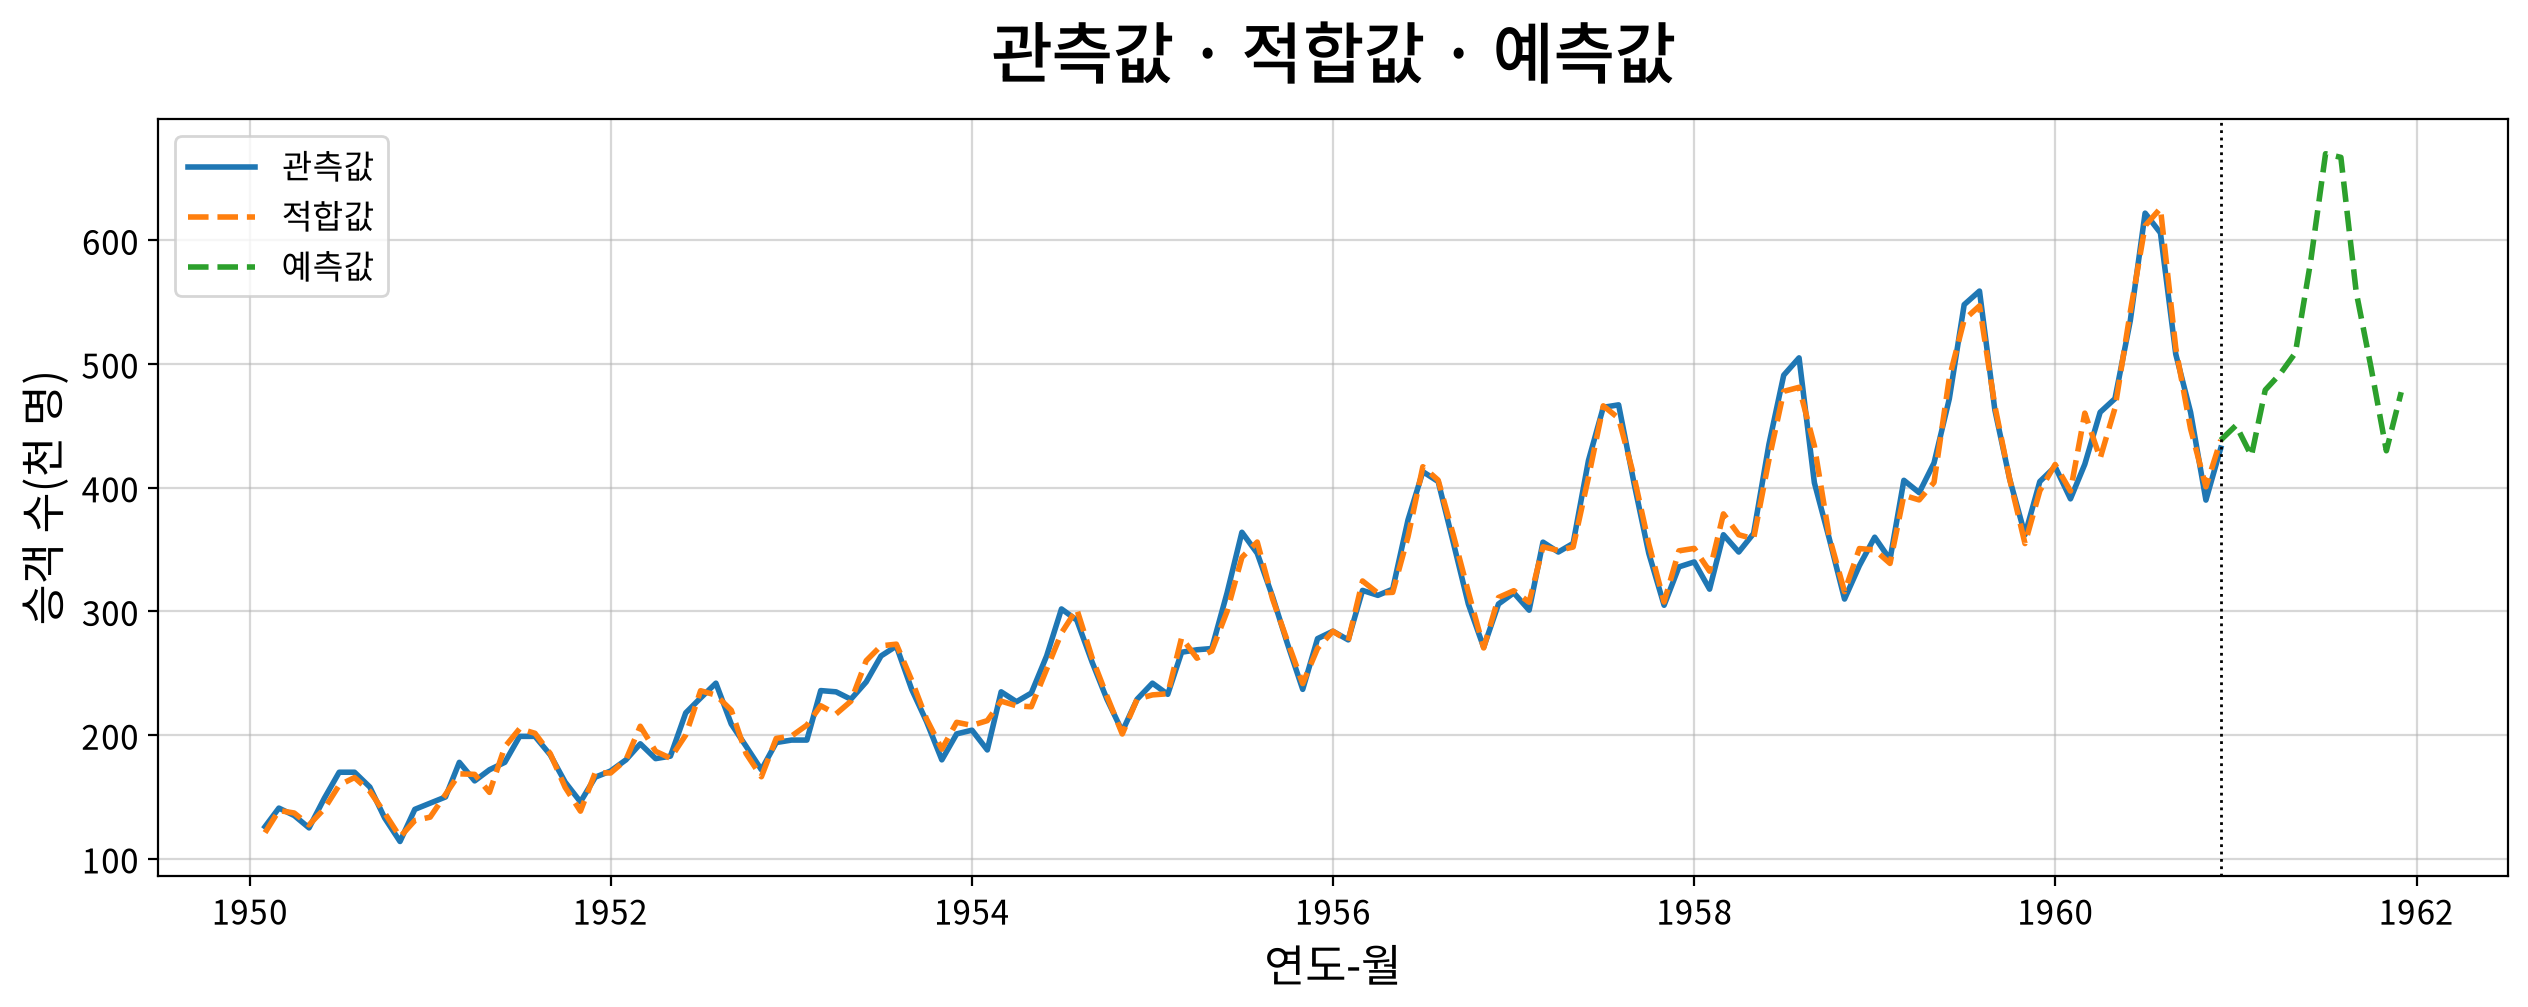

In [47]:
fig, ax = my_plot.init(width=1280, height=520,
                       title="관측값 · 적합값 · 예측값",
                       xlabel="연도-월", ylabel="승객 수(천 명)")

# 적합 구간의 마지막 시점. 관측이 끝나고 예측이 시작되는 경계다
last = df2["적합"].last_valid_index()

# 그대로 그리면 1960-12(적합)와 1961-01(예측) 사이가 끊겨 보인다
# 적합의 마지막 값을 예측선의 출발점으로 붙여 선을 이어준다
predicted = df2["예측"].copy()
predicted[last] = df2.loc[last, "적합"]

my_plot.lineplot(x=df2.index, y=df2["실제"].values, label="관측값", ax=ax)
my_plot.lineplot(x=df2.index, y=df2["적합"].values, label="적합값", linestyle="--", ax=ax)
my_plot.lineplot(x=df2.index, y=predicted.values, label="예측값", linestyle="--", ax=ax)

# 경계 표시: 이 선의 오른쪽은 실제 값이 존재하지 않는 구간이다
ax.axvline(last, color="black", linestyle=":", linewidth=1)

ax.legend()
my_plot.show()

#### 💡 인사이트

- **적합값이 관측값의 봉우리와 골짜기를 거의 정확히 따라간다.** 계절 패턴을 제대로 학습했다는 증거다.
- 계수가 **단 2개**(`ma.L1`, `ma.S.L12`)뿐인데 12년치 계절 변동을 재현한다.
  4단원에서 후보를 좁혀 둔 덕분이다.

> ⚠️ **"잘 겹친다"는 것만으로는 좋은 모형이라고 말할 수 없다.**
> 겹치는 정도를 **숫자로 재고**, 잔차에 남은 패턴이 없는지 **검정으로 확인**해야 한다.
> 그것이 6단원에서 할 일이다.

## #04. 모듈화 기능 확인

### 1. 차수 탐색 + 최적 모형 적합

In [12]:
# 원본 데이터에서 다시 시작한다
source = my_ts.set_index(origin, "Month", freq="MS")

best_fit = my_ts.fit_model(source, "Passengers",
                           p=p, d=d, q=q, P=P, D=D, Q=Q, s=s, log=True)

시도한 조합 16가지 | 적합 성공 16가지 | 로그변환 적용
AIC 최적: (0,1,1)(0,1,1,12)  |  BIC 최적: (0,1,1)(0,1,1,12)


,모형,p,d,q,P,D,Q,s,계수 수,AIC,BIC
순위,,,,,,,,,,,
1,"(0,1,1)(0,1,1,12)",0,1,1,0,1,1,12,3,-483.393,-474.767
2,"(0,1,1)(1,1,1,12)",0,1,1,1,1,1,12,4,-481.906,-470.406
3,"(1,1,1)(0,1,1,12)",1,1,1,0,1,1,12,4,-481.893,-470.392
4,"(1,1,0)(0,1,1,12)",1,1,0,0,1,1,12,3,-481.484,-472.858
5,"(1,1,1)(1,1,1,12)",1,1,1,1,1,1,12,5,-480.304,-465.928
6,"(1,1,0)(1,1,1,12)",1,1,0,1,1,1,12,4,-479.723,-468.223
7,"(0,1,1)(1,1,0,12)",0,1,1,1,1,0,12,3,-477.399,-468.773
8,"(1,1,1)(1,1,0,12)",1,1,1,1,1,0,12,4,-475.460,-463.959
9,"(1,1,0)(1,1,0,12)",1,1,0,1,1,0,12,3,-474.813,-466.187


### 2. 앞으로 1개 시즌 예측

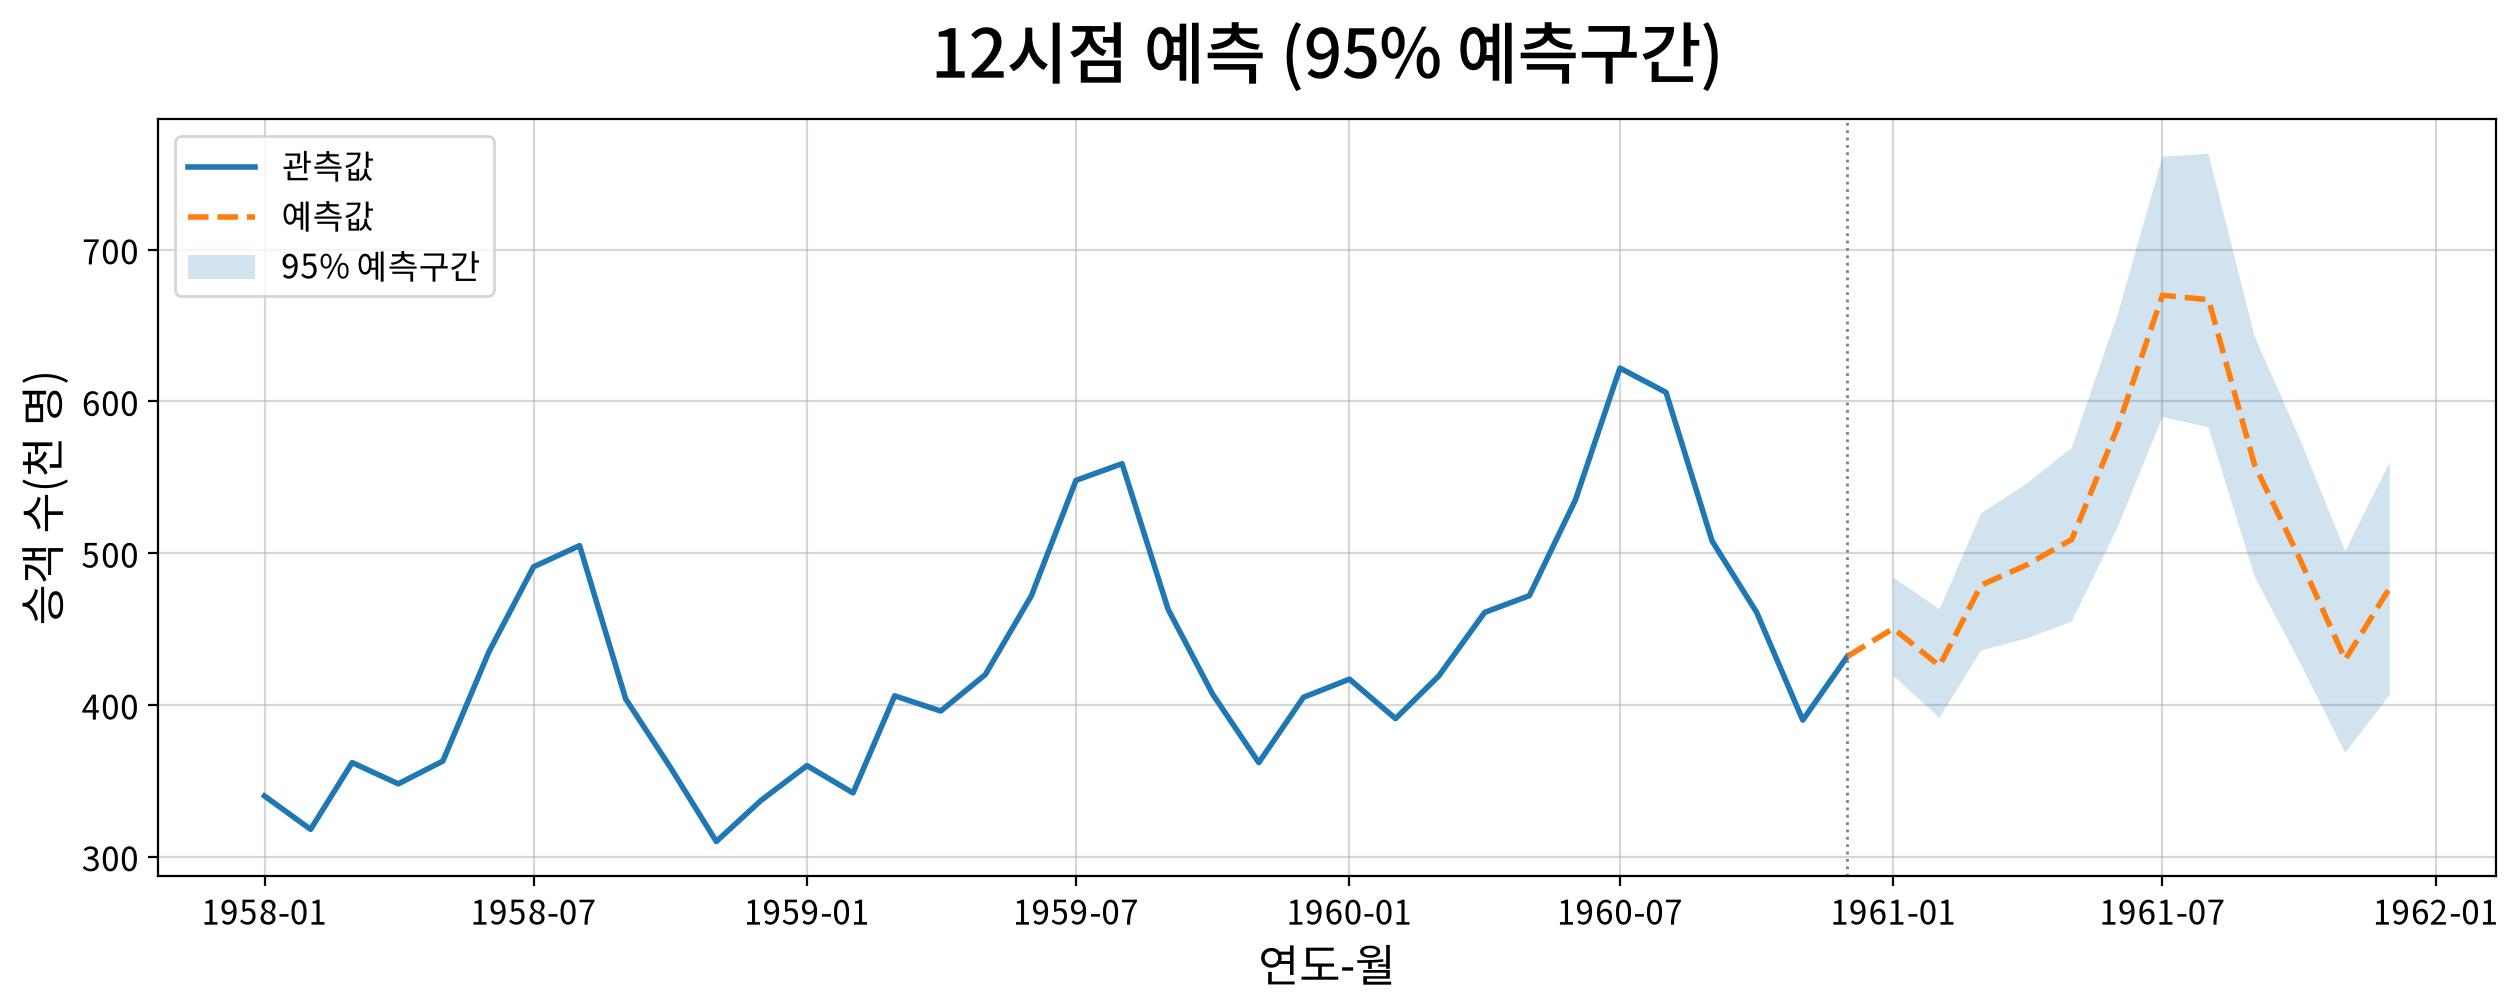

,pred,lower,upper
시점,,,
1961-01-01,450.421,419.151,484.025
1961-02-01,425.712,391.472,462.946
1961-03-01,478.989,435.905,526.332
1961-04-01,492.404,443.936,546.164
1961-05-01,509.057,455.026,569.504
1961-06-01,583.342,517.284,657.835
1961-07-01,670.016,589.718,761.249
1961-08-01,667.079,583.000,763.284
1961-09-01,558.184,484.567,642.985


In [48]:
my_ts.predict(best_fit, steps=s, history=36,
              xlabel="연도-월", ylabel="승객 수(천 명)")